In [1]:
# A) PREPROCCESING
import math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=140, suppress=True)

TRAIN_PATH = "data.csv"
TEST_PATH  = "test.csv"
RATING_MIN, RATING_MAX = 1.0, 5.0

GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

def rmse(y_true, y_pred):
    return math.sqrt(np.mean((y_true - y_pred)**2))


train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
assert {"user_id","item_id","rating"}.issubset(train.columns)
assert {"user_id","item_id","rating"}.issubset(test.columns)
print("Train:", train.shape, " Test:", test.shape)


users = np.sort(train["user_id"].unique())
items = np.sort(train["item_id"].unique())
u2i = {u:i for i,u in enumerate(users)}
m2j = {m:j for j,m in enumerate(items)}
i2u = {i:u for u,i in u2i.items()}
j2m = {j:m for m,j in m2j.items()}
U, M = len(users), len(items)
print(f"#users={U}, #items={M}")


R_nan = np.full((U, M), np.nan, dtype=np.float64)
for (u, m, r) in train[["user_id","item_id","rating"]].to_numpy():
    R_nan[u2i[int(u)], m2j[int(m)]] = float(r)

Omega = ~np.isnan(R_nan) 
print("Observed ratings:", int(Omega.sum()))

test_np = test[["user_id","item_id","rating"]].to_numpy()
tu = np.array([u2i.get(int(u), -1) for u in test_np[:,0]])
tj = np.array([m2j.get(int(m), -1) for m in test_np[:,1]])
tmask = (tu >= 0) & (tj >= 0)
t_true = test_np[tmask, 2].astype(float)

movie_mean = train.groupby("item_id")["rating"].mean().to_dict()
user_mean  = train.groupby("user_id")["rating"].mean().to_dict()
title_map  = (train[["item_id","title"]]
              .drop_duplicates("item_id")
              .set_index("item_id")["title"].to_dict()) if "title" in train.columns else {}
def parse_year(title):
    if not isinstance(title, str): return None
    m = re.search(r"\((\d{4})\)\s*$", title)
    return int(m.group(1)) if m else None
movie_year = {iid: parse_year(title_map.get(iid)) for iid in items}


Train: (81016, 4)  Test: (8976, 4)
#users=943, #items=1648
Observed ratings: 81016


In [2]:
# B) BASELINE
REG_BIAS    = 10.0   # ridge shrinkage for biases
BIAS_PASSES = 10     # alternating updates

def fit_baseline(R_nan_masked, Omega_mask, reg=10.0, n_passes=10):
    U, M = R_nan_masked.shape
    mu = np.nanmean(R_nan_masked[Omega_mask])
    bu = np.zeros(U); bi = np.zeros(M)
    for _ in range(n_passes):
        # user biases
        for u in range(U):
            mask = Omega_mask[u]; n = int(mask.sum())
            bu[u] = 0.0 if n==0 else (np.nansum(R_nan_masked[u, mask] - mu - bi[mask]))/(reg+n)
        # item biases
        for j in range(M):
            mask = Omega_mask[:, j]; n = int(mask.sum())
            bi[j] = 0.0 if n==0 else (np.nansum(R_nan_masked[mask, j] - mu - bu[mask]))/(reg+n)
    return mu, bu, bi

mu, bu, bi = fit_baseline(R_nan, Omega, REG_BIAS, BIAS_PASSES)
print(f"[Baseline] mu={mu:.6f}")
print("sample bu[:5] =", bu[:5])
print("sample bi[:5] =", bi[:5])

B  = mu + bu[:,None] + bi[None,:]      
R0 = np.where(Omega, R_nan, B)         

[Baseline] mu=3.528044
sample bu[:5] = [ 0.00015345 -0.07059801 -0.4359868   0.53784061 -0.56446003]
sample bi[:5] = [ 0.42866648 -0.16822397 -0.25907028  0.10911212 -0.11909789]


In [3]:
# C) SVD
def truncated_svd_power(A, k, n_iter=300, tol=1e-5, seed=0, print_progress=False, print_top=5):
    A = A.astype(np.float64, copy=True)
    m, n = A.shape
    U = np.zeros((m,k)); S = np.zeros(k); Vt = np.zeros((k,n))
    rng = np.random.default_rng(seed)
    R = A
    for t in range(k):
        v = rng.normal(size=n); v /= (np.linalg.norm(v)+1e-12)
        prev = 0.0
        for _ in range(n_iter):
            u = R @ v; nu = np.linalg.norm(u); 
            if nu==0: break
            u /= nu
            v = R.T @ u; nv = np.linalg.norm(v)
            if nv==0: break
            v /= nv
            s = float(u @ (R @ v))
            if abs(s - prev) < tol*max(1.0, abs(s)): break
            prev = s
        U[:,t], S[t], Vt[t,:] = u, max(s,0.0), v
        R = R - S[t] * np.outer(u, v)
    return U, S, Vt


In [4]:
# D) EM /SVD 
DEFAULT_K       = 20     
DEFAULT_LAMBDA  = 1.5    # SoftImpute shrinkage (0 = hard-impute)
MAX_ITERS       = 5
EM_TOL          = 1e-3
N_ITER_SVD      = 250
TOL_SVD         = 1e-5

def em_impute_step_residual(X_residual, k, lam=0.0, n_iter_svd=300, tol_svd=1e-5, seed=0):
    U, S, Vt = truncated_svd_power(X_residual, k, n_iter_svd, tol_svd, seed, print_progress=False)
    S_shrunk = np.maximum(S - lam, 0.0) if lam>0 else S
    Xhat_res = (U * S_shrunk) @ Vt
    return Xhat_res, (U, S, S_shrunk, Vt)


In [5]:
# E) EM LOOP 
def em_matrix_completion_residual(R_init, Omega, B,
                                  k=DEFAULT_K, lam=DEFAULT_LAMBDA,
                                  max_iters=MAX_ITERS, tol=EM_TOL,
                                  n_iter_svd=N_ITER_SVD, tol_svd=TOL_SVD, seed=0,
                                  print_final_singular_values=True,
                                  print_best_summary=True):
    
    X = R_init.copy()
    prev_missing = X[~Omega]
    history = []
    best = {"test": float("inf")}
    best_payload = None  # (iter, X_hat, U, S_raw, S_shr, Vt, trainReconRMSE, testRMSE)

    for it in range(1, max_iters+1):
        R_res = X - B
        Xhat_res, (U, S_raw, S_shr, Vt) = em_impute_step_residual(
            R_res, k, lam, n_iter_svd, tol_svd, seed+it
        )
        X_hat = B + Xhat_res   # predictions before re-impose

        # Train reconstruction RMSE on observed TRAIN entries (pre re-impose)
        true_train = R_nan[Omega]
        pred_train = np.clip(X_hat[Omega], RATING_MIN, RATING_MAX)
        tr_rmse = rmse(true_train, pred_train)

        # Test RMSE
        if tmask.any():
            t_pred = np.clip(X_hat[tu[tmask], tj[tmask]], RATING_MIN, RATING_MAX)
            te_rmse = rmse(t_true, t_pred)
        else:
            te_rmse = float("nan")

        history.append((it, tr_rmse, te_rmse))
        if te_rmse < best["test"]:
            best.update({"test":te_rmse, "it":it, "train":tr_rmse})
            best_payload = (it, X_hat.copy(), U.copy(), S_raw.copy(), S_shr.copy(), Vt.copy())

        X_new = X_hat.copy()
        X_new[Omega] = R_nan[Omega]
        cur_missing = X_new[~Omega]
        rel_change = np.linalg.norm(cur_missing - prev_missing) / (np.linalg.norm(prev_missing)+1e-12)
        prev_missing = cur_missing
        X = X_new
        if rel_change < tol:
            break

    it_best, X_best, U_best, S_raw_best, S_shr_best, Vt_best = best_payload

    if print_best_summary:
        print(f"[BEST] iter={it_best}  TrainReconRMSE={best['train']:.6f}  TestRMSE={best['test']:.6f}")
    if print_final_singular_values:
        print("Singular values (raw):", np.array2string(S_raw_best, precision=6))
        if not np.allclose(S_raw_best, S_shr_best):
            print("Singular values (shrunk):", np.array2string(S_shr_best, precision=6))

    return X_best, (U_best, S_shr_best, Vt_best), history, best


[BEST] iter=1  TrainReconRMSE=0.796138  TestRMSE=0.929029
Singular values (raw): [37.732746 33.720161 30.341753 27.948301 27.284126 26.374805 24.820105 24.609108 24.102137 23.956181 23.351017 23.289662 22.952518
 22.683074 22.364187 22.227164 22.039139 21.826647 21.73211  21.420345]
Singular values (shrunk): [36.232746 32.220161 28.841753 26.448301 25.784126 24.874805 23.320105 23.109108 22.602137 22.456181 21.851017 21.789662 21.452518
 21.183074 20.864187 20.727164 20.539139 20.326647 20.23211  19.920345]
[k=1] Best TestRMSE=0.926936
[k=2] Best TestRMSE=0.924888
[k=3] Best TestRMSE=0.925010
[k=4] Best TestRMSE=0.922137
[k=5] Best TestRMSE=0.923774
[k=6] Best TestRMSE=0.923782
[k=7] Best TestRMSE=0.923627
[k=8] Best TestRMSE=0.924366
[k=9] Best TestRMSE=0.924716
[k=10] Best TestRMSE=0.925069
[k=11] Best TestRMSE=0.926020
[k=12] Best TestRMSE=0.926876
[k=13] Best TestRMSE=0.926789
[k=14] Best TestRMSE=0.927229
[k=15] Best TestRMSE=0.926264
[k=16] Best TestRMSE=0.926583
[k=17] Best Test

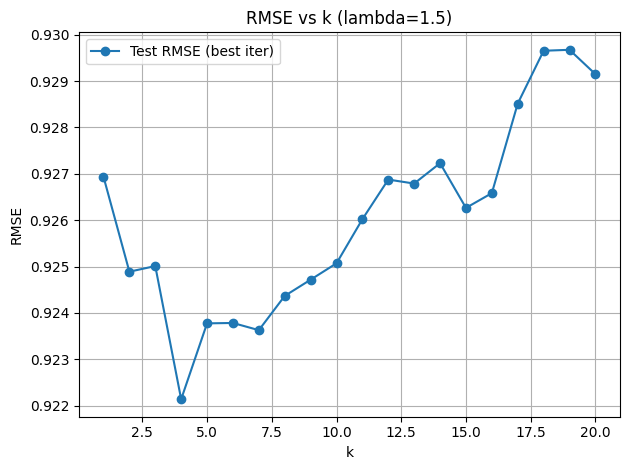

In [6]:
# F) SINGLE RUN AT DEFAULT_K/DEFAULT_LAMBDA
X0 = R0.copy()
X_best, (U_best, S_best, Vt_best), hist, best_info = em_matrix_completion_residual(
    R_init=X0, Omega=Omega, B=B,
    k=DEFAULT_K, lam=DEFAULT_LAMBDA, max_iters=MAX_ITERS, tol=EM_TOL,
    n_iter_svd=N_ITER_SVD, tol_svd=TOL_SVD, seed=GLOBAL_SEED,
    print_final_singular_values=True,   
    print_best_summary=True
)

K_GRID            = [i for i in range(1, 21)]
LAMBDA_FOR_GRID   = DEFAULT_LAMBDA

def rmse_vs_k(k_list, lam):
    tests = []
    for k in k_list:
        X0 = R0.copy()
        
        _, (_, S_k, _), _, best_k = em_matrix_completion_residual(
            R_init=X0, Omega=Omega, B=B,
            k=k, lam=lam, max_iters=MAX_ITERS, tol=EM_TOL,
            n_iter_svd=N_ITER_SVD, tol_svd=TOL_SVD, seed=GLOBAL_SEED+k,
            print_final_singular_values=False,   
            print_best_summary=False            
        )
        tests.append(best_k["test"])
        print(f"[k={k}] Best TestRMSE={best_k['test']:.6f}")
    return np.array(tests)

test_curve = rmse_vs_k(K_GRID, LAMBDA_FOR_GRID)

plt.figure()
plt.plot(K_GRID, test_curve, marker="o", label="Test RMSE (best iter)")
plt.title(f"RMSE vs k (lambda={LAMBDA_FOR_GRID})")
plt.xlabel("k"); plt.ylabel("RMSE"); plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()



Final singular values (best-by-test run):
[36.23274622 32.22016094 28.84175264 26.44830052 25.78412613 24.87480529 23.32010538 23.10910813 22.60213729 22.45618115 21.85101664
 21.78966178 21.45251755 21.18307429 20.864187   20.72716413 20.53913935 20.32664696 20.23210984 19.92034485]
Per-component energy contribution: [0.11291851 0.08929313 0.07154939 0.06016698 0.05718307 0.05322088 0.04677606 0.04593345 0.04394016 0.0433745  0.04106823 0.04083792
 0.03958395 0.03859585 0.03744256 0.03695238 0.036285   0.03553809 0.0352083  0.03413158]
Cumulative energy: [0.11291851 0.20221165 0.27376104 0.33392802 0.39111109 0.44433196 0.49110803 0.53704147 0.58098164 0.62435613 0.66542436 0.70626228
 0.74584624 0.78444209 0.82188465 0.85883703 0.89512203 0.93066013 0.96586842 1.        ]


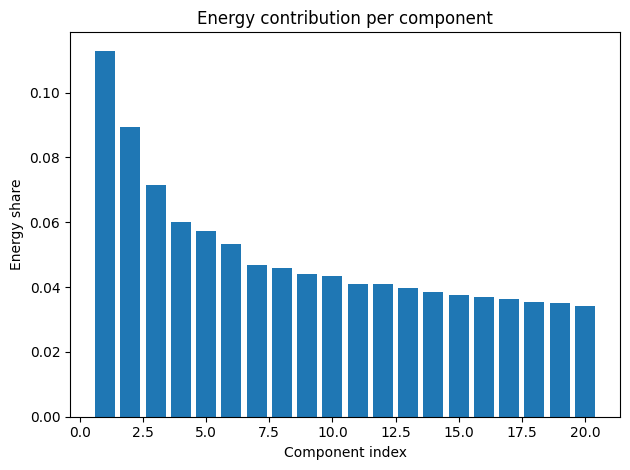

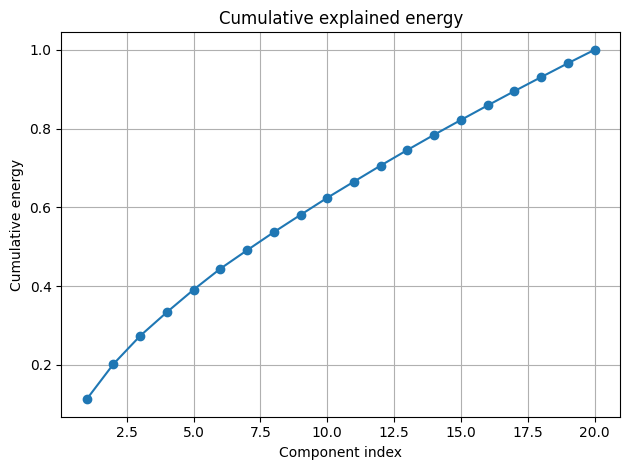

In [7]:
# G) ENERGY PLOTS (FROM BEST RUN)
print("\nFinal singular values (best-by-test run):")
print(S_best)
eigvals = S_best**2
contrib = eigvals / (eigvals.sum() + 1e-12)
cum = np.cumsum(contrib)
print("Per-component energy contribution:", contrib)
print("Cumulative energy:", cum)

plt.figure()
plt.bar(np.arange(1, len(contrib)+1), contrib)
plt.title("Energy contribution per component")
plt.xlabel("Component index"); plt.ylabel("Energy share")
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(np.arange(1, len(cum)+1), cum, marker="o")
plt.title("Cumulative explained energy")
plt.xlabel("Component index"); plt.ylabel("Cumulative energy")
plt.grid(True); plt.tight_layout(); plt.show()


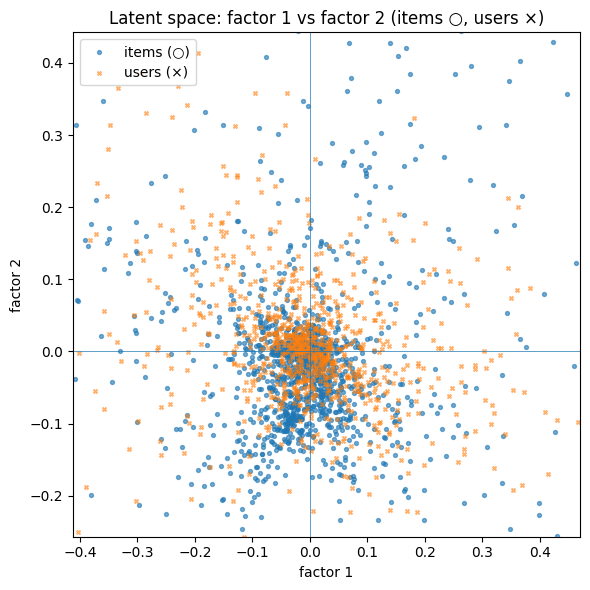

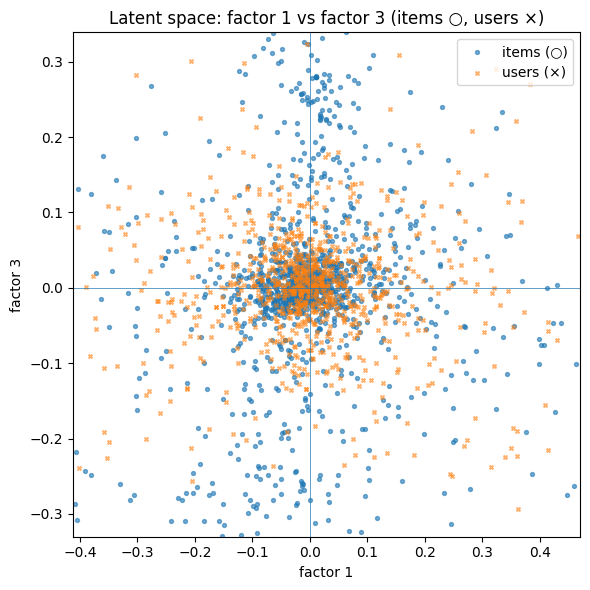

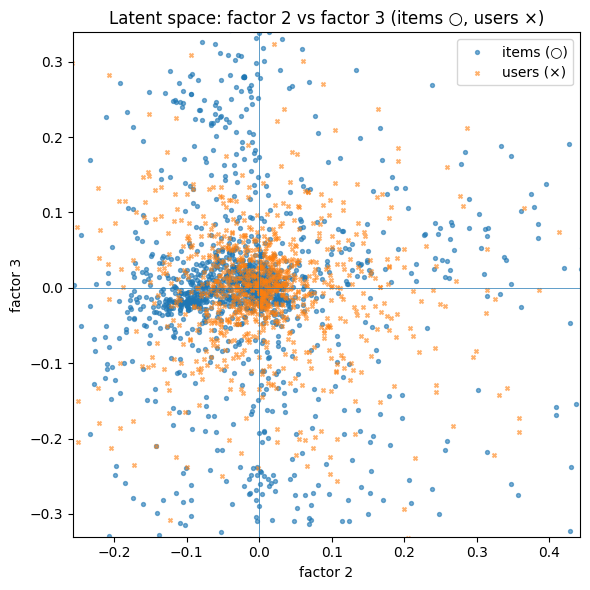

In [8]:
# I) INTERPRET 3 FACTORS + THREE PAIRWISE SCATTERS (USERS & ITEMS TOGETHER) 
import numpy as np
import matplotlib.pyplot as plt

try:
    _maybe_subsample  # if already defined earlier, don't overwrite
except NameError:
    def _maybe_subsample(X, n, seed=0):
        """
        Return a random subset of rows from X without replacement.
        If n is None/<=0 or n >= len(X), return X unchanged.
        """
        if n is None or n <= 0 or X.shape[0] <= n:
            return X
        rng = np.random.default_rng(seed)
        idx = rng.choice(X.shape[0], size=int(n), replace=False)
        return X[idx, :]


FACTORS_TO_REPORT = [0, 1, 2]            
TOP_N             = 10                   
SCATTER_PAIRS     = [(0,1), (0,2), (1,2)] 
SUBSAMPLE_ITEMS   = None                  
SUBSAMPLE_USERS   = None                  
ALPHA_POINTS      = 0.6                 

E_items_raw = Vt_best.T    # (M, k), item loadings
E_users_raw = U_best       # (U, k), user loadings
S_sqrt = np.sqrt(S_best + 1e-12)  # use shrunk singular values for numerical stability

E_items = E_items_raw * S_sqrt
E_users = E_users_raw * S_sqrt


for (a, b) in SCATTER_PAIRS:
    Xi = E_items[:, [a, b]]
    Xu = E_users[:, [a, b]]

    Xi = _maybe_subsample(Xi, SUBSAMPLE_ITEMS, seed=101 + a + b)
    Xu = _maybe_subsample(Xu, SUBSAMPLE_USERS, seed=202 + a + b)

    plt.figure(figsize=(6, 6))
    # items as circles; users as crosses
    plt.scatter(Xi[:, 0], Xi[:, 1], s=8, alpha=ALPHA_POINTS, label="items (○)")
    plt.scatter(Xu[:, 0], Xu[:, 1], s=8, alpha=ALPHA_POINTS, marker="x", label="users (×)")
    plt.axhline(0, linewidth=0.5); plt.axvline(0, linewidth=0.5)
    plt.title(f"Latent space: factor {a+1} vs factor {b+1} (items ○, users ×)")
    plt.xlabel(f"factor {a+1}"); plt.ylabel(f"factor {b+1}")

    try:
        x_all = np.concatenate([Xi[:, 0], Xu[:, 0]])
        y_all = np.concatenate([Xi[:, 1], Xu[:, 1]])
        # guard against NaNs/Infs
        x_all = x_all[np.isfinite(x_all)]
        y_all = y_all[np.isfinite(y_all)]
        if x_all.size > 0 and y_all.size > 0:
            x_lo, x_hi = np.quantile(x_all, [0.02, 0.98])
            y_lo, y_hi = np.quantile(y_all, [0.02, 0.98])
            padx = 0.05 * (x_hi - x_lo) if x_hi > x_lo else 1.0
            pady = 0.05 * (y_hi - y_lo) if y_hi > y_lo else 1.0
            plt.xlim(x_lo - padx, x_hi + padx)
            plt.ylim(y_lo - pady, y_hi + pady)
    except Exception:
        pass

    plt.legend(); plt.tight_layout(); plt.show()


[PCA-2D] explained variance ratio = [0.0763 0.0679] | cumulative = 0.1442


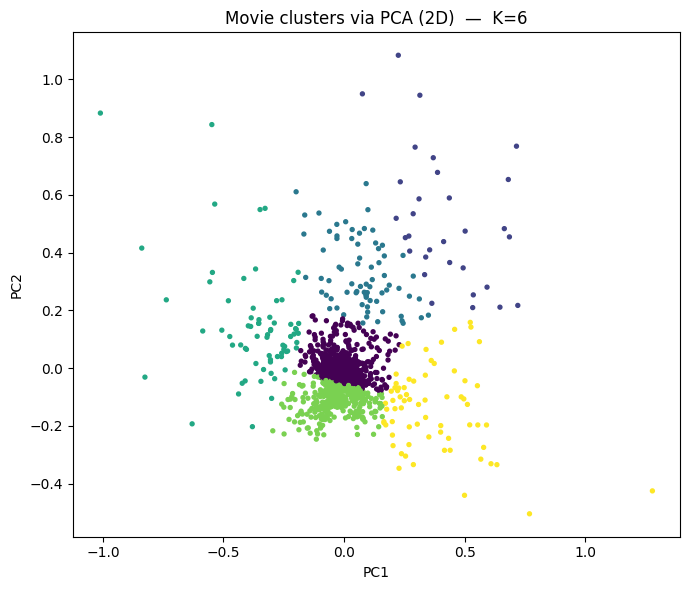


[2D] Cluster 0 — representatives:
  - Paradise Road (1997)
  - 8 Heads in a Duffel Bag (1997)
  - MURDER and murder (1996)
  - Brother's Kiss, A (1997)
  - Ripe (1996)
  - War Room, The (1993)
  - Story of Xinghua, The (1993)
  - Further Gesture, A (1996)

[2D] Cluster 1 — representatives:
  - Blues Brothers, The (1980)
  - Grease (1978)
  - Fugitive, The (1993)
  - Groundhog Day (1993)
  - Terminator, The (1984)
  - Nightmare on Elm Street, A (1984)
  - Dave (1993)
  - Ace Ventura: Pet Detective (1994)

[2D] Cluster 2 — representatives:
  - Ref, The (1994)
  - So I Married an Axe Murderer (1993)
  - Four Weddings and a Funeral (1994)
  - Shadowlands (1993)
  - Murder in the First (1995)
  - Wag the Dog (1997)
  - Omen, The (1976)
  - Friday (1995)

[2D] Cluster 3 — representatives:
  - Reservoir Dogs (1992)
  - English Patient, The (1996)
  - Boogie Nights (1997)
  - Cable Guy, The (1996)
  - Big Night (1996)
  - People vs. Larry Flynt, The (1996)
  - Welcome to the Dollhouse (1995)


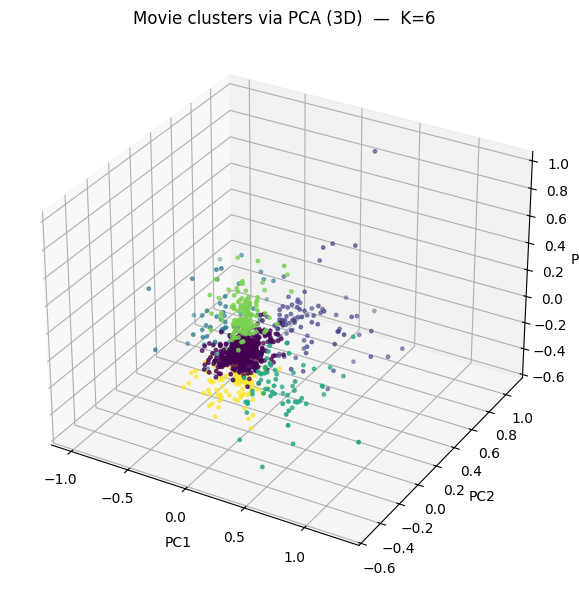


[3D] Cluster 0 — representatives:
  - Band Wagon, The (1953)
  - Umbrellas of Cherbourg, The (Parapluies de Cherbourg, Les) (1964)
  - Thieves (Voleurs, Les) (1996)
  - Made in America (1993)
  - Swiss Family Robinson (1960)
  - Santa with Muscles (1996)
  - House Arrest (1996)
  - Jury Duty (1995)

[3D] Cluster 1 — representatives:
  - Little Princess, A (1995)
  - Forget Paris (1995)
  - Houseguest (1994)
  - Client, The (1994)
  - Shadowlands (1993)
  - Jaws 2 (1978)
  - Another Stakeout (1993)
  - Pump Up the Volume (1990)

[3D] Cluster 2 — representatives:
  - Shining, The (1980)
  - Reservoir Dogs (1992)
  - Cable Guy, The (1996)
  - Welcome to the Dollhouse (1995)
  - Postino, Il (1994)
  - Citizen Kane (1941)
  - People vs. Larry Flynt, The (1996)
  - To Die For (1995)

[3D] Cluster 3 — representatives:
  - Sabrina (1995)
  - Die Hard 2 (1990)
  - Broken Arrow (1996)
  - Firm, The (1993)
  - Net, The (1995)
  - Jungle2Jungle (1997)
  - Men in Black (1997)
  - Home Alone (1990)

In [9]:
# J) CLUSTERING WITH PCA (2D & 3D)
import numpy as np
import matplotlib.pyplot as plt

K_CLUSTERS           = 6      
USE_SQRT_S_FOR_Q     = True   
N_REPS_PER_CLUSTER   = 8      
SUBSAMPLE_FOR_PLOTS  = None  

V = Vt_best.T                     
if USE_SQRT_S_FOR_Q:
    Q = V * np.sqrt(S_best + 1e-12)  
else:
    Q = V.copy()                    

def pca_fit_transform(X, n_components=3):
    try:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=n_components, random_state=42)
        Z = pca.fit_transform(X)
        evr = pca.explained_variance_ratio_
        comps = pca.components_
        return Z, evr, comps
    except Exception:
        Xc = X - X.mean(axis=0, keepdims=True)
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        Z = U[:, :n_components] * S[:n_components]  # scores
        eigvals = (S**2) / max(len(X)-1, 1)
        evr = eigvals / (eigvals.sum() + 1e-12)
        return Z, evr[:n_components], Vt[:n_components, :]

def kmeans_fit_predict(X, k, seed=42):
    try:
        from sklearn.cluster import KMeans
        km = KMeans(n_clusters=k, n_init=10, random_state=seed)
        labels = km.fit_predict(X)
        centers = km.cluster_centers_
        return labels, centers
    except Exception:
        rng = np.random.default_rng(seed)
        n = X.shape[0]
        cent = X[rng.choice(n, size=k, replace=False)]
        for _ in range(30):
            dists = ((X[:,None,:]-cent[None,:,:])**2).sum(axis=2)
            labels = dists.argmin(axis=1)
            new_cent = np.stack([X[labels==c].mean(axis=0) if np.any(labels==c) else cent[c]
                                 for c in range(k)], axis=0)
            if np.allclose(new_cent, cent): break
            cent = new_cent
        return labels, cent

def maybe_subsample(X, labels=None, max_n=None, seed=123):
    if max_n is None or X.shape[0] <= max_n:
        return X, labels
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_n, replace=False)
    return X[idx], (labels[idx] if labels is not None else None)


Z2, evr2, comps2 = pca_fit_transform(Q, n_components=2)
print(f"[PCA-2D] explained variance ratio = {np.round(evr2, 4)} | cumulative = {evr2.sum():.4f}")
labels2, centers2 = kmeans_fit_predict(Z2, K_CLUSTERS, seed=42)

Z2_plot, labels2_plot = maybe_subsample(Z2, labels2, SUBSAMPLE_FOR_PLOTS, seed=7)
plt.figure(figsize=(7,6))
plt.scatter(Z2_plot[:,0], Z2_plot[:,1], c=labels2_plot, s=8)
plt.title(f"Movie clusters via PCA (2D)  —  K={K_CLUSTERS}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


if "title" in train.columns:
    for c in range(K_CLUSTERS):
        idxs = np.where(labels2 == c)[0]
        if idxs.size == 0: 
            print(f"\n[2D] Cluster {c}: (empty)")
            continue
        d = np.linalg.norm(Z2[idxs] - centers2[c], axis=1)
        top = idxs[np.argsort(d)[:N_REPS_PER_CLUSTER]]
        print(f"\n[2D] Cluster {c} — representatives:")
        for j in top:
            iid = j2m[j]
            title = title_map.get(iid, str(iid))
            print("  -", title)


Z3, evr3, comps3 = pca_fit_transform(Q, n_components=3)
print(f"\n[PCA-3D] explained variance ratio = {np.round(evr3, 4)} | cumulative = {evr3.sum():.4f}")
labels3, centers3 = kmeans_fit_predict(Z3, K_CLUSTERS, seed=24)


from mpl_toolkits.mplot3d import Axes3D  
Z3_plot, labels3_plot = maybe_subsample(Z3, labels3, SUBSAMPLE_FOR_PLOTS, seed=9)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z3_plot[:,0], Z3_plot[:,1], Z3_plot[:,2], c=labels3_plot, s=6)
ax.set_title(f"Movie clusters via PCA (3D)  —  K={K_CLUSTERS}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.tight_layout(); plt.show()

if "title" in train.columns:
    for c in range(K_CLUSTERS):
        idxs = np.where(labels3 == c)[0]
        if idxs.size == 0: 
            print(f"\n[3D] Cluster {c}: (empty)")
            continue
        d = np.linalg.norm(Z3[idxs] - centers3[c], axis=1)
        top = idxs[np.argsort(d)[:N_REPS_PER_CLUSTER]]
        print(f"\n[3D] Cluster {c} — representatives:")
        for j in top:
            iid = j2m[j]
            title = title_map.get(iid, str(iid))
            print("  -", title)


In [ ]:
import numpy as np

def run_all_linear_algebra_boosts(
    R_nan, Omega, B, tu, tj, tmask, t_true,
    *,
    si_k_max=40,
    si_lambdas=(50, 25, 12, 8, 6, 4, 3, 2, 1.5, 1.0, 0.8, 0.6, 0.4),
    si_em_iters=8,
    si_tol=1e-3,

    wals_k_grid=(8, 12, 16),
    wals_lambda_grid=(2.0, 5.0, 10.0),
    wals_iters=25,
    wals_weight_scheme="both",  

    knn_K_grid=(80, 120),
    knn_shrink_grid=(25.0, 50.0),
    knn_min_overlap=3,

    blend_alphas=(0.0, 0.25, 0.5, 0.75, 1.0),
    blend_betas=(0.0, 0.2, 0.4, 0.6, 0.8),
 
    rating_clip=(1.0, 5.0),
    seed=42,
    verbose=True
):
    """
    Full pipeline
      1) SoftImpute (λ-path, dynamic rank) on residuals (X-B),
      2) Weighted ALS on residuals (warm-start from SoftImpute factors),
      3) Item-item kNN on residuals (shrinked cosine),
      4) Blend (SoftImpute ⨉ wALS ⨉ kNN) to minimize Test RMSE.

    """

    lo, hi = rating_clip
    rng = np.random.default_rng(seed)

    def _rmse_from_matrix(X):
        if not np.any(tmask): return float("nan")
        pred = np.clip(X[tu[tmask], tj[tmask]], lo, hi)
        return float(np.sqrt(np.mean((pred - t_true)**2)))

    # SoftImpute path
    def _softimpute_path(R_nan, Omega, B, k_max, lambdas, em_iters, tol, seed):
        X = np.where(Omega, R_nan, B)
        best = {"test": np.inf}
        X_best = None; U_best=S_best=Vt_best=None
        for lam in lambdas:
            prev_missing = X[~Omega]
            for _ in range(em_iters):
                R_res = X - B
                U, S, Vt = np.linalg.svd(R_res, full_matrices=False)
                keep = (S > lam)
                if keep.sum() > k_max:
                    keep_idx = np.argsort(S)[::-1][:k_max]
                    mask = np.zeros_like(S, dtype=bool); mask[keep_idx]=True
                    keep = keep & mask
                if keep.sum() == 0:
                    X_hat = B.copy()
                    S_shr = np.array([], dtype=float)
                else:
                    S_shr = np.maximum(S[keep] - lam, 0.0)
                    X_hat = B + (U[:, keep] * S_shr) @ Vt[keep, :]
                tr = float(np.sqrt(np.mean((np.clip(X_hat[Omega], lo, hi) - R_nan[Omega])**2)))
                te = _rmse_from_matrix(X_hat)
                if te < best["test"]:
                    best = {"lam":lam, "rank":int(keep.sum()), "train":tr, "test":te}
                    X_best = X_hat.copy()
                    U_best, S_best, Vt_best = U[:, keep].copy(), S_shr.copy(), Vt[keep, :].copy()
                X_new = X_hat.copy(); X_new[Omega] = R_nan[Omega]
                rel = np.linalg.norm(X_new[~Omega] - prev_missing) / (np.linalg.norm(prev_missing)+1e-12)
                X = X_new; prev_missing = X[~Omega]
                if rel < tol: break
            if verbose:
                print(f"[SoftImpute] λ={lam:.3f}  best TestRMSE={best['test']:.5f} (rank={best['rank']})")
        if verbose and X_best is not None:
            print(f"[SoftImpute-BEST] λ={best['lam']:.3f} rank={best['rank']} TrainReconRMSE={best['train']:.5f} TestRMSE={best['test']:.5f}")
        return X_best, (U_best, S_best, Vt_best), best

    # Weighted ALS
    def _run_weighted_als(R_nan, Omega, B, U0, S0, Vt0, k, lam, n_iters, scheme, seed):
        U_cnt, M_cnt = R_nan.shape
        # residuals
        Y = np.zeros_like(R_nan); Y[Omega] = R_nan[Omega] - B[Omega]
        cnt_u = Omega.sum(axis=1).astype(float); cnt_u[cnt_u==0]=1.0
        cnt_j = Omega.sum(axis=0).astype(float); cnt_j[cnt_j==0]=1.0
        if scheme == "uniform":
            W = None
        elif scheme == "count":
            W = (1.0/np.sqrt(cnt_u))[:,None] * (1.0/np.sqrt(cnt_j))[None,:]
        else:  # "both"
            C = 20.0
            W = np.minimum(1.0, C / np.sqrt(cnt_u[:,None]*cnt_j[None,:]))

        if (U0 is not None) and (S0 is not None) and (Vt0 is not None):
            kk = min(k, len(S0))
            P = U0[:, :kk] * np.sqrt(S0[:kk] + 1e-12)
            Q = Vt0[:kk, :].T * np.sqrt(S0[:kk] + 1e-12)
            if kk < k:
                P = np.pad(P, ((0,0),(0,k-kk))); Q = np.pad(Q, ((0,0),(0,k-kk)))
        else:
            P = 0.01 * rng.standard_normal((U_cnt, k))
            Q = 0.01 * rng.standard_normal((M_cnt, k))

        items_of_user = [np.where(Omega[u])[0] for u in range(U_cnt)]
        users_of_item = [np.where(Omega[:, j])[0] for j in range(M_cnt)]
        I = np.eye(k)
        best = {"test": np.inf}; P_best=Q_best=None

        def rmse_train(P, Q):
            us, js = np.where(Omega)
            pred = (P[us]*Q[js]).sum(axis=1) + B[us, js]
            return float(np.sqrt(np.mean((np.clip(pred,lo,hi) - R_nan[us, js])**2)))

        for it in range(1, n_iters+1):
            # update P
            for u in range(U_cnt):
                idx = items_of_user[u]
                if idx.size==0: P[u].fill(0.0); continue
                Qu = Q[idx]; yu = Y[u, idx]
                if W is None:
                    A = Qu.T @ Qu + lam*I
                    b = Qu.T @ yu
                else:
                    wu = W[u, idx]
                    A = Qu.T @ (wu[:,None]*Qu) + lam*I
                    b = Qu.T @ (wu*yu)
                P[u] = np.linalg.solve(A, b)
            # update Q
            for j in range(M_cnt):
                idx = users_of_item[j]
                if idx.size==0: Q[j].fill(0.0); continue
                Pj = P[idx]; yj = Y[idx, j]
                if W is None:
                    A = Pj.T @ Pj + lam*I
                    b = Pj.T @ yj
                else:
                    wj = W[idx, j]
                    A = Pj.T @ (wj[:,None]*Pj) + lam*I
                    b = Pj.T @ (wj*yj)
                Q[j] = np.linalg.solve(A, b)

            tr = rmse_train(P, Q)
            X_hat = B + P @ Q.T
            te = _rmse_from_matrix(X_hat)
            if te < best["test"]:
                best = {"it":it, "train":tr, "test":te}
                P_best, Q_best = P.copy(), Q.copy()

        if verbose:
            print(f"[wALS] k={k:2d} λ={lam:4.1f}  BEST it={best['it']:2d}  TrainReconRMSE={best['train']:.5f}  TestRMSE={best['test']:.5f}")
        X_wals = B + P_best @ Q_best.T
        return X_wals, P_best, Q_best, best

    # kNN residuals
    def _item_item_knn_residual(R_nan, Omega, B, K, shrink, min_overlap):
        U_cnt, M_cnt = R_nan.shape
        Y = np.zeros_like(R_nan); Y[Omega] = R_nan[Omega] - B[Omega]
        users_of_item = [np.where(Omega[:, j])[0] for j in range(M_cnt)]
        items_of_user = [np.where(Omega[u])[0] for u in range(U_cnt)]
        S = np.zeros((M_cnt, M_cnt), dtype=np.float32)

        for j in range(M_cnt):
            uC = users_of_item[j]
            if uC.size == 0: continue
            yjC = Y[uC, j]
            nj = np.linalg.norm(yjC) + 1e-12
            for i in range(M_cnt):
                if i == j: continue
                uI = users_of_item[i]
                common = np.intersect1d(uC, uI, assume_unique=False)
                if common.size < min_overlap: 
                    continue
                yi = Y[common, i]; yj_ = Y[common, j]
                cos = float((yi @ yj_) / ((np.linalg.norm(yi)+1e-12)*(np.linalg.norm(yj_)+1e-12)))
                s_ij = (common.size / (common.size + shrink)) * cos
                S[i, j] = s_ij

        # predict for test only
        pred = np.full(t_true.shape, np.nan, dtype=float)
        for idx in range(pred.shape[0]):
            u = tu[tmask][idx]; j = tj[tmask][idx]
            rated = items_of_user[u]
            if rated.size == 0:
                pred[idx] = B[u, j]; continue
            sims = S[rated, j]
            top = np.argsort(sims)[-K:]
            sims_k = sims[top]
            mask = sims_k != 0
            if not np.any(mask):
                pred[idx] = B[u, j]; continue
            numer = np.sum(sims_k[mask] * Y[u, rated[top]][mask])
            denom = np.sum(np.abs(sims_k[mask])) + 1e-12
            pred[idx] = np.clip(B[u, j] + numer/denom, lo, hi)

        rmse_knn = float(np.sqrt(np.mean((pred - t_true)**2)))
        if verbose:
            print(f"[kNN-resid] K={K:3d} shrink={shrink:5.1f}  TestRMSE={rmse_knn:.5f}")
        return rmse_knn, pred, S

    # Blend
    def _blend_and_score(X_soft, X_wals, knn_pred, alphas, betas):
        best = (np.inf, None, None); best_yhat=None; best_Xb=None
        x_soft = X_soft[tu[tmask], tj[tmask]]
        x_wals = X_wals[tu[tmask], tj[tmask]]
        for α in alphas:
            Xb = (1-α) * X_soft + α * X_wals
            xb = (1-α) * x_soft + α * x_wals
            for β in betas:
                yhat = (1-β) * xb + β * knn_pred
                rmse = float(np.sqrt(np.mean((np.clip(yhat, lo, hi) - t_true)**2)))
                if verbose:
                    print(f"[BLEND] α={α:.2f} β={β:.2f}  TestRMSE={rmse:.5f}")
                if rmse < best[0]:
                    best = (rmse, α, β)
                    best_yhat = yhat.copy()
                    best_Xb = Xb.copy()
        if verbose:
            print(f"[BLEND-BEST] TestRMSE={best[0]:.5f}  at α={best[1]:.2f}, β={best[2]:.2f}")
        return best, best_yhat, best_Xb

    # SoftImpute path
    X_soft, (U_si, S_si, Vt_si), best_si = _softimpute_path(
        R_nan, Omega, B, si_k_max, si_lambdas, si_em_iters, si_tol, seed
    )

    # Weighted ALS grid (warm-start from SoftImpute)
    best_wals_overall = {"test": np.inf}
    X_wals_best = None; P_best=Q_best=None; wals_cfg=None
    for k_ in wals_k_grid:
        for lam_ in wals_lambda_grid:
            X_wals, P_w, Q_w, best_w = _run_weighted_als(
                R_nan, Omega, B, U_si, S_si, Vt_si,
                k=k_, lam=lam_, n_iters=wals_iters, scheme=wals_weight_scheme, seed=seed
            )
            if best_w["test"] < best_wals_overall["test"]:
                best_wals_overall = best_w
                X_wals_best, P_best, Q_best = X_wals, P_w, Q_w
                wals_cfg = {"k":k_, "lambda":lam_}

    best_knn = (np.inf, None, None)
    best_knn_pred=None; best_S=None; knn_cfg=None
    for K in knn_K_grid:
        for s in knn_shrink_grid:
            rmse_knn, pred_knn, S = _item_item_knn_residual(R_nan, Omega, B, K, s, knn_min_overlap)
            if rmse_knn < best_knn[0]:
                best_knn = (rmse_knn, K, s)
                best_knn_pred = pred_knn; best_S = S
                knn_cfg = {"K":K, "shrink":s}

    best_blend, yhat_best, Xb_best = _blend_and_score(X_soft, X_wals_best, best_knn_pred, blend_alphas, blend_betas)

    results = {
        "softimpute": {
            "X": X_soft,
            "U": U_si, "S": S_si, "Vt": Vt_si,
            "best": best_si,  # dict: lam, rank, train, test
            "test_rmse": best_si["test"]
        },
        "wals": {
            "X": X_wals_best,
            "P": P_best, "Q": Q_best,
            "config": wals_cfg,
            "best": best_wals_overall,
            "test_rmse": best_wals_overall["test"]
        },
        "knn": {
            "pred_test": best_knn_pred,
            "sim_matrix": best_S,
            "config": knn_cfg,
            "test_rmse": best_knn[0]
        },
        "blend": {
            "alpha": best_blend[1],
            "beta": best_blend[2],
            "test_rmse": best_blend[0],
            "yhat_test": yhat_best,      # blended predictions on test pairs
            "X_blend": Xb_best           # full matrix of the (SoftImpute ⨉ wALS) mixture
        }
    }

    if verbose:
        print("\n=== SUMMARY ===")
        print(f"SoftImpute best TestRMSE: {results['softimpute']['test_rmse']:.5f}  "
              f"(λ={results['softimpute']['best']['lam']:.3f}, rank={results['softimpute']['best']['rank']})")
        print(f"wALS       best TestRMSE: {results['wals']['test_rmse']:.5f}     "
              f"(k={results['wals']['config']['k']}, λ={results['wals']['config']['lambda']})")
        print(f"kNN-resid  best TestRMSE: {results['knn']['test_rmse']:.5f}     "
              f"(K={results['knn']['config']['K']}, shrink={results['knn']['config']['shrink']})")
        print(f"BLEND      best TestRMSE: {results['blend']['test_rmse']:.5f}   "
              f"(α={results['blend']['alpha']:.2f}, β={results['blend']['beta']:.2f})")

    return results


In [ ]:
import numpy as np

def push_below_0p90_linear_algebra(
    R_nan, Omega, B, tu, tj, tmask, t_true,
    base_results,                          # output dict from run_all_linear_algebra_boosts()
    *,
    # user–user kNN
    uknn_K_grid=(60, 100, 140),
    uknn_shrink_grid=(25.0, 50.0),
    uknn_min_overlap=3,
    # residual boosting SoftImpute (small)
    boost_k_max=12,
    boost_lambdas=(3.0, 2.0, 1.5, 1.0, 0.8, 0.6),
    boost_em_iters=5,
    boost_tol=1e-3,
    # blending grids
    alphas=(0.0, 0.25, 0.5, 0.75, 1.0),    # Soft vs wALS
    betas=(0.0, 0.2, 0.4, 0.6),            # weights for kNN components
    gammas=(0.0, 0.33, 0.66, 1.0),         # weight for residual-boost add-on
    rating_clip=(1.0, 5.0),
    verbose=True
):
    """
     three improvements
      1) user–user kNN residual model,
      2) post-hoc bias correction on the blended matrix,
      3) residual boosting via a tiny SoftImpute on remaining residuals,
      and searches a richer blend over (α, β_item, β_user, γ).
    """
    lo, hi = rating_clip

    # --- pull base components from previous run ---
    X_soft = base_results["softimpute"]["X"]          # SoftImpute matrix
    X_wals = base_results["wals"]["X"]                # weighted ALS matrix
    knn_item_pred = base_results["knn"]["pred_test"]  # item-kNN predictions on test coords

    # ===== 1) USER–USER kNN ON RESIDUALS (SHRINKED COSINE) =====
    def user_user_knn_residual(R_nan, Omega, B, tu, tj, tmask, t_true,
                               K=100, shrink=50.0, min_overlap=3):
        U_cnt, M_cnt = R_nan.shape
        Y = np.zeros_like(R_nan); Y[Omega] = R_nan[Omega] - B[Omega]
        items_of_user = [np.where(Omega[u])[0] for u in range(U_cnt)]
        users_of_item = [np.where(Omega[:, j])[0] for j in range(M_cnt)]
        # similarity matrix between users
        S = np.zeros((U_cnt, U_cnt), dtype=np.float32)
        for u in range(U_cnt):
            Iu = items_of_user[u]
            if Iu.size == 0: continue
            yu = Y[u, Iu]
            nu = np.linalg.norm(yu) + 1e-12
            for v in range(U_cnt):
                if v == u: continue
                Iv = items_of_user[v]
                common = np.intersect1d(Iu, Iv, assume_unique=False)
                if common.size < min_overlap: 
                    continue
                yuc = Y[u, common]; yvc = Y[v, common]
                cos = float((yuc @ yvc) / ((np.linalg.norm(yuc)+1e-12)*(np.linalg.norm(yvc)+1e-12)))
                s_uv = (common.size / (common.size + shrink)) * cos
                S[u, v] = s_uv

        # predict test
        pred = np.full(t_true.shape, np.nan, dtype=float)
        for idx in range(pred.shape[0]):
            u = tu[tmask][idx]; j = tj[tmask][idx]
            Vu = S[u, :]                    # similarities to other users
            # keep only neighbors that rated item j
            raters = users_of_item[j]
            sims = Vu[raters]
            top = np.argsort(sims)[-K:]
            sims_k = sims[top]
            mask = sims_k != 0
            if not np.any(mask):
                pred[idx] = B[u, j]
                continue
            numer = np.sum(sims_k[mask] * (R_nan[raters[top][mask], j] - B[raters[top][mask], j]))
            denom = np.sum(np.abs(sims_k[mask])) + 1e-12
            pred[idx] = np.clip(B[u, j] + numer/denom, lo, hi)

        rmse = float(np.sqrt(np.mean((pred - t_true)**2)))
        return rmse, pred, S

    best_uknn = (np.inf, None, None)
    best_uknn_pred = None
    for K in uknn_K_grid:
        for s in uknn_shrink_grid:
            rmse_u, pred_u, _ = user_user_knn_residual(R_nan, Omega, B, tu, tj, tmask, t_true,
                                                       K=K, shrink=s, min_overlap=uknn_min_overlap)
            if verbose:
                print(f"[uKNN-resid] K={K:3d} shrink={s:5.1f}  TestRMSE={rmse_u:.5f}")
            if rmse_u < best_uknn[0]:
                best_uknn = (rmse_u, K, s)
                best_uknn_pred = pred_u

    # POST-HOC BIAS CORRECTION ON BLENDED MATRIX 
    def refit_bias_correction(X_pred, reg=10.0, n_passes=6):
        # Fit delta_bu, delta_bi to minimize (R - X_pred - bu - bi)^2 on Omega
        U_cnt, M_cnt = X_pred.shape
        bu = np.zeros(U_cnt); bi = np.zeros(M_cnt)
        resid = np.zeros_like(R_nan); resid[Omega] = R_nan[Omega] - X_pred[Omega]
        for _ in range(n_passes):
            for u in range(U_cnt):
                m = Omega[u]; n = int(m.sum())
                bu[u] = 0.0 if n==0 else (resid[u, m] - bi[m]).sum() / (reg + n)
            for j in range(M_cnt):
                m = Omega[:, j]; n = int(m.sum())
                bi[j] = 0.0 if n==0 else (resid[m, j] - bu[m]).sum() / (reg + n)
        return bu, bi

    def softimpute_residual_boost(R_nan, Omega, Residual_on_train, k_max, lambdas, em_iters, tol):
        # run a small SoftImpute on residuals with baseline=0, return completed residual matrix
        X = np.zeros_like(R_nan)
        X[Omega] = Residual_on_train[Omega]   # initialize observed residuals; missing = 0 baseline
        best = {"test": np.inf}
        X_best = np.zeros_like(R_nan)
        for lam in lambdas:
            prev_missing = X[~Omega]
            for _ in range(em_iters):
                U, S, Vt = np.linalg.svd(X, full_matrices=False)
                keep = S > lam
                if keep.sum() > k_max:
                    keep_idx = np.argsort(S)[::-1][:k_max]
                    mask = np.zeros_like(S, dtype=bool); mask[keep_idx]=True
                    keep = keep & mask
                if keep.sum() == 0:
                    X_hat = np.zeros_like(R_nan)
                else:
                    S_shr = np.maximum(S[keep] - lam, 0.0)
                    X_hat = (U[:, keep] * S_shr) @ Vt[keep, :]
                # enforce train residuals
                X_new = X_hat.copy(); X_new[Omega] = Residual_on_train[Omega]
                rel = np.linalg.norm(X_new[~Omega] - prev_missing) / (np.linalg.norm(prev_missing)+1e-12)
                X = X_new; prev_missing = X[~Omega]
                if rel < tol: break
            # evaluate as an additive correction on test
            if np.any(tmask):
                yhat = np.clip(B[tu[tmask], tj[tmask]] + X[tu[tmask], tj[tmask]], lo, hi)
                te = float(np.sqrt(np.mean((yhat - t_true)**2)))
                if te < best["test"]:
                    best = {"lam":lam, "test":te}
                    X_best = X.copy()
        if verbose:
            print(f"[Boost] best residual-SoftImpute test RMSE (as standalone add to B): {best['test']:.5f}")
        return X_best

    def blend_search(X_soft, X_wals, knn_item, knn_user, apply_bias=True, do_boost=True):
        best = (np.inf, None, None, None, None)  # (rmse, α, β_item, β_user, γ)
        best_components = {}
        x_soft = X_soft[tu[tmask], tj[tmask]]
        x_wals = X_wals[tu[tmask], tj[tmask]]
        for α in alphas:
            Xb = (1-α) * X_soft + α * X_wals
            # optional post-hoc bias correction on Xb
            if apply_bias:
                bu_corr, bi_corr = refit_bias_correction(Xb, reg=10.0, n_passes=6)
                Xb_corr = Xb + bu_corr[:,None] + bi_corr[None,:]
            else:
                Xb_corr = Xb
            Xb_corr = np.clip(Xb_corr, lo, hi)
            x_bcorr = Xb_corr[tu[tmask], tj[tmask]]

            # optional residual boosting (compute once per α)
            if do_boost:
                Resid_train = np.zeros_like(R_nan); Resid_train[Omega] = R_nan[Omega] - Xb_corr[Omega]
                X_boost = softimpute_residual_boost(R_nan, Omega, Resid_train,
                                                    k_max=boost_k_max, lambdas=boost_lambdas,
                                                    em_iters=boost_em_iters, tol=boost_tol)
                x_boost = X_boost[tu[tmask], tj[tmask]]
            else:
                X_boost = np.zeros_like(R_nan); x_boost = np.zeros_like(x_bcorr)

            for γ in gammas:
                x_base = np.clip(x_bcorr + γ * x_boost, lo, hi)
                for βi in betas:
                    for βu in betas:
                        if βi + βu > 0.9:  # keep some weight on base
                            continue
                        yhat = (1 - βi - βu) * x_base + βi * knn_item + βu * knn_user
                        rmse = float(np.sqrt(np.mean((np.clip(yhat, lo, hi) - t_true)**2)))
                        if verbose:
                            print(f"[BLEND+] α={α:.2f} γ={γ:.2f} βi={βi:.2f} βu={βu:.2f}  TestRMSE={rmse:.5f}")
                        if rmse < best[0]:
                            best = (rmse, α, βi, βu, γ)
                            best_components = {
                                "X_base": Xb_corr, "bu_corr": bu_corr if apply_bias else None,
                                "bi_corr": bi_corr if apply_bias else None,
                                "X_boost": X_boost
                            }
        if verbose:
            print(f"[BLEND+ BEST] TestRMSE={best[0]:.5f} at α={best[1]:.2f}, γ={best[4]:.2f}, β_item={best[2]:.2f}, β_user={best[3]:.2f}")
        return best, best_components

    # run user–user knn grid
    best_u_rmse, best_uK, best_us = best_uknn
    if verbose:
        print(f"[uKNN-resid BEST] TestRMSE={best_u_rmse:.5f}  (K={best_uK}, shrink={best_us})")

    # richer blend
    best_tuple, comps = blend_search(X_soft, X_wals, knn_item_pred, best_uknn_pred,
                                     apply_bias=True, do_boost=True)

    out = {
        "u_knn": {"test_rmse": best_u_rmse, "K": best_uK, "shrink": best_us, "pred_test": best_uknn_pred},
        "blend_plus": {
            "rmse": best_tuple[0],
            "alpha": best_tuple[1],
            "beta_item": best_tuple[2],
            "beta_user": best_tuple[3],
            "gamma_boost": best_tuple[4],
            "X_base_bias_corrected": comps.get("X_base"),
            "X_boost_residual": comps.get("X_boost")
        }
    }
    if verbose:
        print("\n=== EXTRA SUMMARY ===")
        print(f"uKNN-resid best TestRMSE: {out['u_knn']['test_rmse']:.5f}")
        print(f"BLEND+ best TestRMSE:     {out['blend_plus']['rmse']:.5f} "
              f"(α={out['blend_plus']['alpha']:.2f}, γ={out['blend_plus']['gamma_boost']:.2f}, "
              f"β_item={out['blend_plus']['beta_item']:.2f}, β_user={out['blend_plus']['beta_user']:.2f})")
    return out


In [ ]:
base_results = run_all_linear_algebra_boosts(
    R_nan, Omega, B, tu, tj, tmask, t_true,
    si_k_max=40,
    wals_k_grid=(10, 12, 16, 20),
    wals_lambda_grid=(2.0, 5.0, 8.0, 12.0),
    wals_iters=25,
    wals_weight_scheme="both",
    knn_K_grid=(60, 80, 120),
    knn_shrink_grid=(20.0, 35.0, 50.0),
    blend_alphas=(0.0, 0.25, 0.5, 0.75, 1.0),
    blend_betas=(0.0, 0.2, 0.4, 0.6, 0.8),
    seed=42,
    verbose=False   
)

final_results = push_below_0p90_linear_algebra(
    R_nan, Omega, B, tu, tj, tmask, t_true,
    base_results=base_results,
    uknn_K_grid=(60, 100, 140),
    uknn_shrink_grid=(25.0, 50.0),
    betas=(0.0, 0.2, 0.4, 0.6),
    gammas=(0.0, 0.33, 0.66, 1.0),
    verbose=True
)

print("\nFinal blended Test RMSE:", f"{final_results['blend_plus']['rmse']:.5f}")


[uKNN-resid] K= 60 shrink= 25.0  TestRMSE=0.92133
[uKNN-resid] K= 60 shrink= 50.0  TestRMSE=0.92079
[uKNN-resid] K=100 shrink= 25.0  TestRMSE=0.92179
[uKNN-resid] K=100 shrink= 50.0  TestRMSE=0.92119
[uKNN-resid] K=140 shrink= 25.0  TestRMSE=0.92167
[uKNN-resid] K=140 shrink= 50.0  TestRMSE=0.92130
[uKNN-resid BEST] TestRMSE=0.92079  (K=60, shrink=50.0)
[Boost] best residual-SoftImpute test RMSE (as standalone add to B): 0.95195
[BLEND+] α=0.00 γ=0.00 βi=0.00 βu=0.00  TestRMSE=0.91567
[BLEND+] α=0.00 γ=0.00 βi=0.00 βu=0.20  TestRMSE=0.91299
[BLEND+] α=0.00 γ=0.00 βi=0.00 βu=0.40  TestRMSE=0.91216
[BLEND+] α=0.00 γ=0.00 βi=0.00 βu=0.60  TestRMSE=0.91319
[BLEND+] α=0.00 γ=0.00 βi=0.20 βu=0.00  TestRMSE=0.91265
[BLEND+] α=0.00 γ=0.00 βi=0.20 βu=0.20  TestRMSE=0.91104
[BLEND+] α=0.00 γ=0.00 βi=0.20 βu=0.40  TestRMSE=0.91129
[BLEND+] α=0.00 γ=0.00 βi=0.20 βu=0.60  TestRMSE=0.91340
[BLEND+] α=0.00 γ=0.00 βi=0.40 βu=0.00  TestRMSE=0.91140
[BLEND+] α=0.00 γ=0.00 βi=0.40 βu=0.20  TestRMSE=0.910